In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_CE = df[df['job_title_short'] == 'Cloud Engineer'].copy().explode('job_skills')

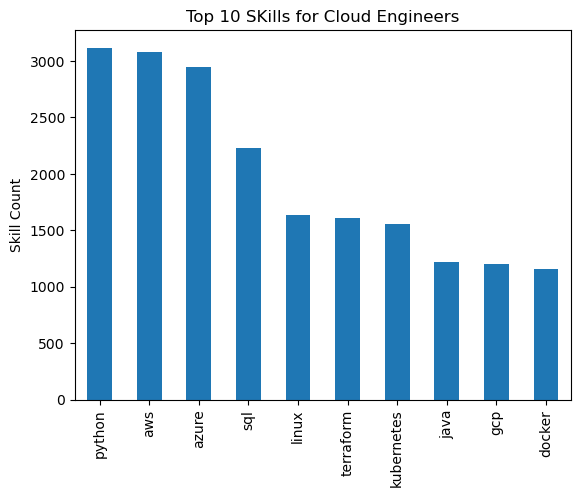

In [27]:
skills_count_CE = df_CE.value_counts('job_skills').head(10)
skills_count_CE.plot(kind='bar')
plt.title('Top 10 SKills for Cloud Engineers')
plt.xlabel('')
plt.ylabel('Skill Count')
plt.show()

In [6]:
df_exploded = df.copy().explode('job_skills')

In [ ]:
skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).size()

job_title_short    job_skills
Business Analyst   airflow        318
                   airtable        17
                   alteryx       1078
                   angular         87
                   ansible        120
                                 ... 
Software Engineer  wrike            4
                   wsl             13
                   xamarin         35
                   yarn           145
                   zoom           229
Length: 2256, dtype: int64

In [12]:
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
266,Cloud Engineer,delphi,1
1920,Senior Data Scientist,objective-c,1
1400,Senior Data Analyst,couchdb,1
298,Cloud Engineer,haskell,1


In [28]:
job_title = 'Data Scientist'
top_skills = 10

df_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills)

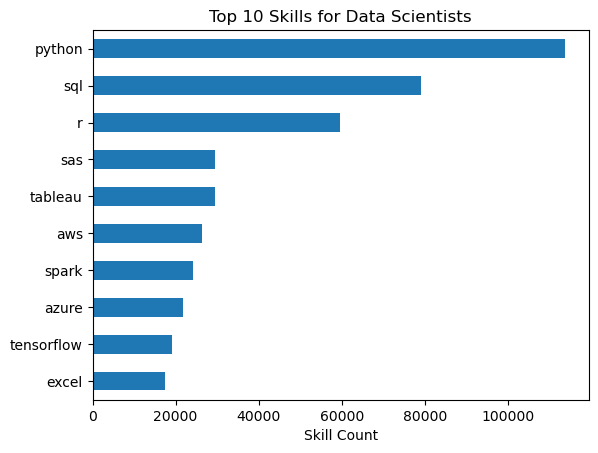

In [29]:
df_final.plot(kind='barh', y='skill_count', x='job_skills')
plt.gca().invert_yaxis()
plt.title(f'Top {top_skills} Skills for {job_title}s')
plt.ylabel('')
plt.xlabel('Skill Count')
plt.legend().set_visible(False)
plt.show()

In [31]:
skill_avg_salary = df_exploded.groupby('job_skills')['salary_year_avg'].mean()

In [37]:
top_skills_salary_wise = skill_avg_salary.reset_index(name='salary_year_avg').sort_values(by='salary_year_avg', ascending=False).head()
top_skills_salary_wise

,job_skills,salary_year_avg
46,debian,196500.000000
177,ringcentral,182500.000000
114,lua,170500.000000
126,mongo,169526.929749
54,dplyr,160667.210526


In [76]:
job_skills_count_pivot = df_exploded.pivot_table(index='job_title_short', values='job_skills', aggfunc='nunique')

In [77]:
job_skills_count_pivot.rename(columns={"job_skills": "num_unique_skills"})

,num_unique_skills
job_title_short,
Business Analyst,223
Cloud Engineer,213
Data Analyst,235
Data Engineer,239
Data Scientist,237
Machine Learning Engineer,222
Senior Data Analyst,207
Senior Data Engineer,226
Senior Data Scientist,215


In [82]:
job_skills_count = df_exploded.groupby('job_title_short')['job_skills'].nunique().reset_index()
job_skills_count.columns = ['job_title_short', 'num_unique_skills']
job_skills_count.head()

,job_title_short,num_unique_skills
0,Business Analyst,223
1,Cloud Engineer,213
2,Data Analyst,235
3,Data Engineer,239
4,Data Scientist,237
